In [1]:
!pip install transformers peft accelerate sentencepiece protobuf sentence-transformers umap-learn scikit-learn -q
!pip install torchao --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.4 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, string
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score
from sklearn.linear_model import Ridge
import umap.umap_ as umap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Connect your google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:
#Change the current working directory
import os
os.chdir('/content/gdrive/My Drive/MARS')

# Print the current working directory
print("Current working directory: {0}".format(os.getcwd()))

Current working directory: /content/gdrive/My Drive/MARS


# Basic Understanding of data

In [6]:
############ Load Dataset ############
df = pd.read_csv("customer_support_tickets.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (20000, 12)

Columns: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']

Dtypes:
 Ticket_ID                object
Customer_Name            object
Customer_Email           object
Ticket_Subject           object
Ticket_Description       object
Issue_Category           object
Priority_Level           object
Ticket_Channel           object
Submission_Date          object
Resolution_Time_Hours     int64
Assigned_Agent           object
Satisfaction_Score        int64
dtype: object

First 3 rows:


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


### Extract key columns

In [7]:
KEY_COLS = [
    "Ticket_ID",
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Priority_Level",
    "Ticket_Channel",
    "Resolution_Time_Hours",
    "Satisfaction_Score"
]

df = df[KEY_COLS].copy()
print("Working dataframe shape:", df.shape)
df.head(3)

Working dataframe shape: (20000, 8)


,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Satisfaction_Score
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,5
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,5
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,5


In [8]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

null_report = pd.DataFrame({
    "null_count": null_counts,
    "null_pct": null_pct
}).sort_values("null_pct", ascending=False)

print(null_report)

                       null_count  null_pct
Ticket_ID                       0       0.0
Ticket_Subject                  0       0.0
Ticket_Description              0       0.0
Issue_Category                  0       0.0
Priority_Level                  0       0.0
Ticket_Channel                  0       0.0
Resolution_Time_Hours           0       0.0
Satisfaction_Score              0       0.0


### Visualisation

In [9]:
priority_order = ["Low", "Medium", "High", "Critical"]
priority_counts = df["Priority_Level"].value_counts().reindex(priority_order)

df["subject_len"] = df["Ticket_Subject"].astype(str).apply(lambda x: len(x.split()))
df["desc_len"] = df["Ticket_Description"].astype(str).apply(lambda x: len(x.split()))

print("Overall text stats:")
print(df[["subject_len", "desc_len"]].describe().round(2))

print("\nAvg description length by priority:")
print(df.groupby("Priority_Level")["desc_len"].mean().round(1).reindex(priority_order))

print("\nAvg resolution time by priority:")
print(df.groupby("Priority_Level")["Resolution_Time_Hours"].mean().round(2).reindex(priority_order))

Overall text stats:
       subject_len  desc_len
count     20000.00  20000.00
mean          4.17     16.93
std           0.38      2.39
min           4.00     10.00
25%           4.00     15.00
50%           4.00     17.00
75%           4.00     19.00
max           5.00     23.00

Avg description length by priority:
Priority_Level
Low         16.6
Medium      16.9
High        17.4
Critical    17.9
Name: desc_len, dtype: float64

Avg resolution time by priority:
Priority_Level
Low         45.17
Medium      44.47
High        24.52
Critical    12.07
Name: Resolution_Time_Hours, dtype: float64


/tmp/ipykernel_3710/3288798566.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


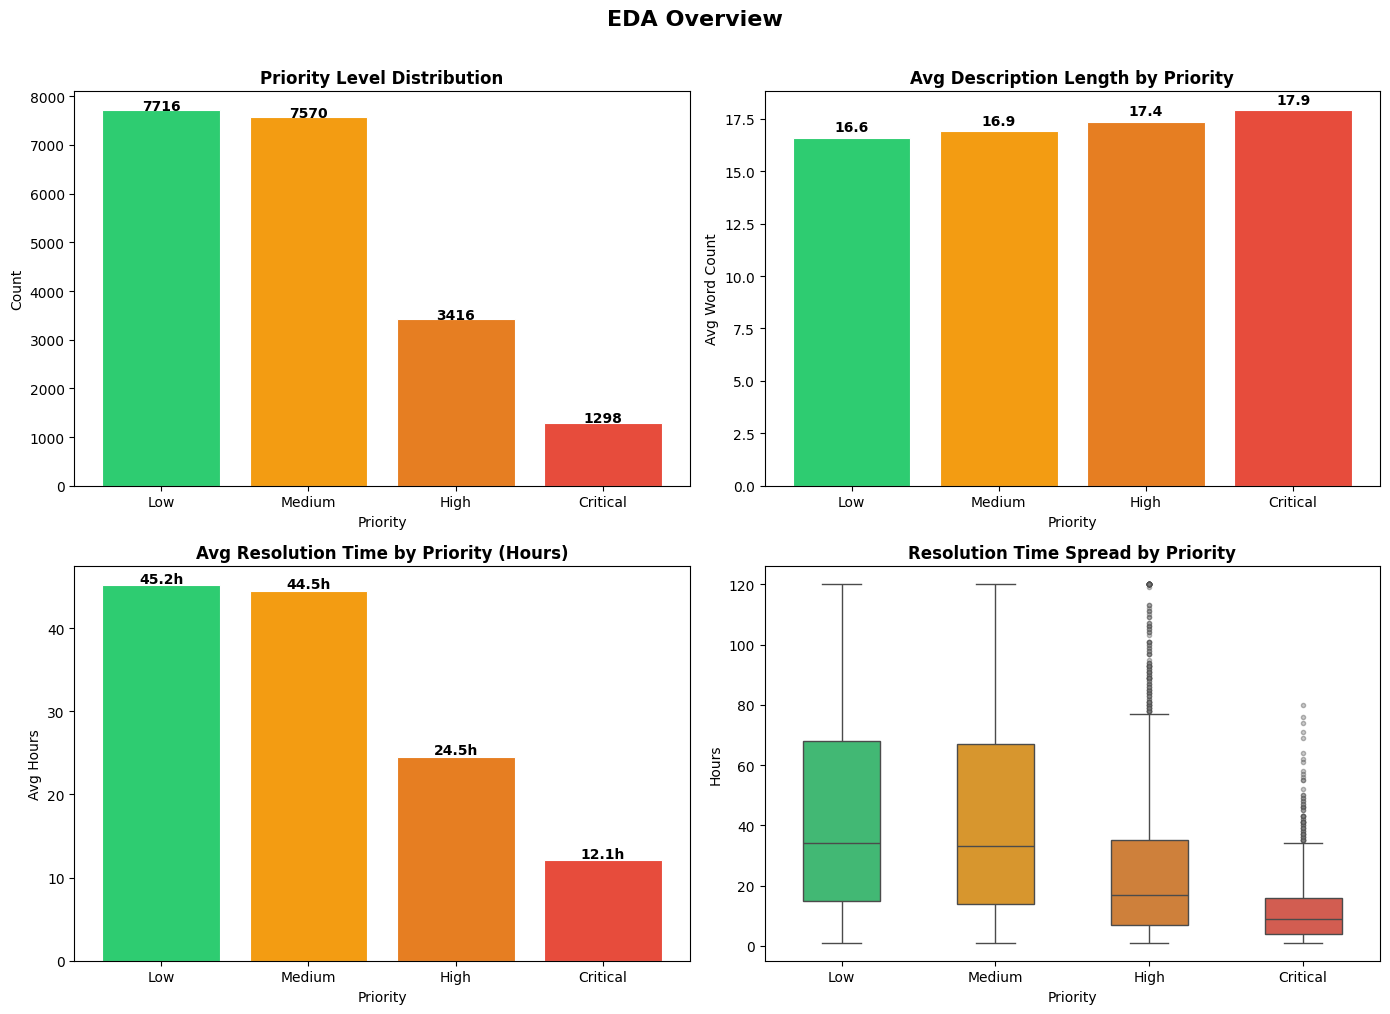

In [10]:
priority_order = ["Low", "Medium", "High", "Critical"]
colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA Overview", fontsize=16, fontweight="bold", y=1.01)

# --- Plot 1: Priority Distribution ---
priority_counts = df["Priority_Level"].value_counts().reindex(priority_order)
axes[0, 0].bar(priority_counts.index, priority_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0, 0].set_title("Priority Level Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Priority")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(priority_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha="center", fontsize=10, fontweight="bold")

# --- Plot 2: Avg Description Length by Priority ---
avg_desc = df.groupby("Priority_Level")["desc_len"].mean().reindex(priority_order)
axes[0, 1].bar(avg_desc.index, avg_desc.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0, 1].set_title("Avg Description Length by Priority", fontweight="bold")
axes[0, 1].set_xlabel("Priority")
axes[0, 1].set_ylabel("Avg Word Count")
for i, v in enumerate(avg_desc.values):
    axes[0, 1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")

# --- Plot 3: Avg Resolution Time by Priority ---
avg_res = df.groupby("Priority_Level")["Resolution_Time_Hours"].mean().reindex(priority_order)
axes[1, 0].bar(avg_res.index, avg_res.values, color=colors, edgecolor="white", linewidth=0.8)
axes[1, 0].set_title("Avg Resolution Time by Priority (Hours)", fontweight="bold")
axes[1, 0].set_xlabel("Priority")
axes[1, 0].set_ylabel("Avg Hours")
for i, v in enumerate(avg_res.values):
    axes[1, 0].text(i, v + 0.3, f"{v:.1f}h", ha="center", fontsize=10, fontweight="bold")

# --- Plot 4: Resolution Time Distribution (Boxplot) ---
priority_palette = dict(zip(priority_order, colors))
sns.boxplot(
    data=df,
    x="Priority_Level",
    y="Resolution_Time_Hours",
    order=priority_order,
    palette=priority_palette,
    ax=axes[1, 1],
    width=0.5,
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4)
)
axes[1, 1].set_title("Resolution Time Spread by Priority", fontweight="bold")
axes[1, 1].set_xlabel("Priority")
axes[1, 1].set_ylabel("Hours")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3710/2754577415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


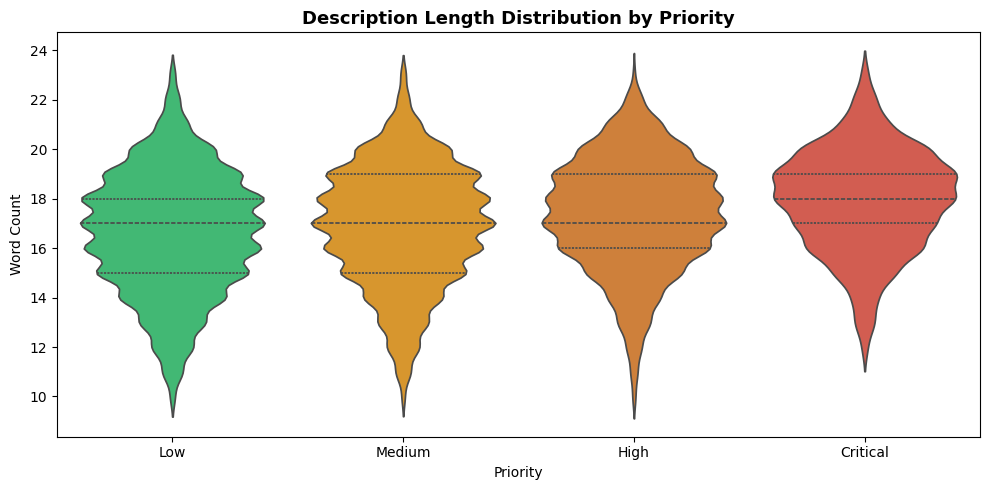

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="Priority_Level",
    y="desc_len",
    order=priority_order,
    palette=priority_palette,
    inner="quartile",
    ax=ax
)
ax.set_title("Description Length Distribution by Priority", fontweight="bold", fontsize=13)
ax.set_xlabel("Priority")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.show()

### Text Preprocessing

In [12]:
import re
import string

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"\S+@\S+", "", text)               # remove emails
    text = re.sub(r"\d+", " ", text)                  # remove standalone numbers
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return text

df["clean_subject"] = df["Ticket_Subject"].apply(clean_text)
df["clean_desc"]    = df["Ticket_Description"].apply(clean_text)

# Combined field — this is what most signals will consume
df["clean_text"] = df["clean_subject"] + " " + df["clean_desc"]

print(df[["Ticket_Subject", "clean_subject", "Ticket_Description", "clean_desc"]].head(3).to_string())

                    Ticket_Subject                  clean_subject                                                                                  Ticket_Description                                                                                       clean_desc
0  Hours of operation - Individual  hours of operation individual                    Hi Support, Where is your headquarters located? Lay soon message show know main.                    hi support where is your headquarters located lay soon message show know main
1          Data not syncing - Card          data not syncing card  Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.  hi support the application crashes every time i open the settings tab speech wall six hour book
2            2FA issues - Question             fa issues question              Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.              hi support how do i upgrade to t

In [13]:
# Spot check a few
for i in range(3):
    print(f"\n--- Ticket {i} ---")
    print("RAW:", df["Ticket_Description"].iloc[i][:200])
    print("CLEAN:", df["clean_text"].iloc[i][:200])


--- Ticket 0 ---
RAW: Hi Support, Where is your headquarters located? Lay soon message show know main.
CLEAN: hours of operation individual hi support where is your headquarters located lay soon message show know main

--- Ticket 1 ---
RAW: Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.
CLEAN: data not syncing card hi support the application crashes every time i open the settings tab speech wall six hour book

--- Ticket 2 ---
RAW: Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.
CLEAN: fa issues question hi support how do i upgrade to the enterprise plan close stand street wear your her


In [14]:
# Check for any empty clean_text after preprocessing
empty_mask = df["clean_text"].str.strip() == ""
print(f"Empty clean_text rows: {empty_mask.sum()}")

# Drop them if any
df = df[~empty_mask].reset_index(drop=True)
print(f"Remaining rows: {len(df)}")

Empty clean_text rows: 0
Remaining rows: 20000


In [15]:
df["clean_text_len"] = df["clean_text"].apply(lambda x: len(x.split()))

print(df["clean_text_len"].describe().round(2))
print("\nAvg cleaned text length by priority:")
print(df.groupby("Priority_Level")["clean_text_len"].mean().round(1).reindex(priority_order))

count    20000.00
mean        19.92
std          2.38
min         13.00
25%         18.00
50%         20.00
75%         22.00
max         27.00
Name: clean_text_len, dtype: float64

Avg cleaned text length by priority:
Priority_Level
Low         19.6
Medium      19.9
High        20.3
Critical    21.0
Name: clean_text_len, dtype: float64


In [16]:
df.head()

,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Satisfaction_Score,subject_len,desc_len,clean_subject,clean_desc,clean_text,clean_text_len
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,5,5,13,hours of operation individual,hi support where is your headquarters located ...,hours of operation individual hi support where...,17
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,5,5,17,data not syncing card,hi support the application crashes every time ...,data not syncing card hi support the applicati...,21
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,5,4,16,fa issues question,hi support how do i upgrade to the enterprise ...,fa issues question hi support how do i upgrade...,19
3,TKT-100003,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,41,5,4,17,login failed let,hi support the dashboard is not loading any da...,login failed let hi support the dashboard is n...,20
4,TKT-100004,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,40,5,4,18,refund status attention,hi support i have been trying to update my pay...,refund status attention hi support i have been...,21


### Encode categorical features

In [17]:
from sklearn.preprocessing import LabelEncoder

print("Unique Priority_Level values:", df["Priority_Level"].unique())
print("\nUnique Ticket_Channel values:", df["Ticket_Channel"].unique())
print("\nUnique Issue_Category values:", df["Issue_Category"].unique())

Unique Priority_Level values: ['High' 'Low' 'Medium' 'Critical']

Unique Ticket_Channel values: ['Web Form' 'Chat' 'Email']

Unique Issue_Category values: ['General Inquiry' 'Technical' 'Account' 'Billing' 'Fraud']


In [18]:
priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_encoded"] = df["Priority_Level"].str.strip().map(priority_map).astype(int)

Split train and test

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["priority_encoded"])

print("Train size:", len(train_df))
print("Test size: ", len(test_df))

Train size: 16000
Test size:  4000


In [20]:
# create encoder
le_channel = LabelEncoder()
train_df["channel_encoded"] = le_channel.fit_transform(train_df["Ticket_Channel"].astype(str))
test_df["channel_encoded"] = le_channel.transform(test_df["Ticket_Channel"].astype(str))

# display mapping
print("Channel mapping:")
print(dict(zip(le_channel.classes_,le_channel.transform(le_channel.classes_))))

Channel mapping:
{'Chat': np.int64(0), 'Email': np.int64(1), 'Web Form': np.int64(2)}


In [21]:
# create encoder
le_category = LabelEncoder()
train_df["category_encoded"] = le_category.fit_transform(train_df["Issue_Category"].astype(str))
test_df["category_encoded"] = le_category.transform(test_df["Issue_Category"].astype(str))

# display mapping
print("\nCategory mapping:")
print(dict(zip(le_category.classes_,le_category.transform(le_category.classes_))))


Category mapping:
{'Account': np.int64(0), 'Billing': np.int64(1), 'Fraud': np.int64(2), 'General Inquiry': np.int64(3), 'Technical': np.int64(4)}


### Normalization

In [22]:
print(df[["Resolution_Time_Hours","Satisfaction_Score"]].describe().round(2))
print("\nNulls in resolution time:", df["Resolution_Time_Hours"].isnull().sum())

       Resolution_Time_Hours  Satisfaction_Score
count               20000.00            20000.00
mean                   39.23                3.72
std                    35.22                1.29
min                     1.00                1.00
25%                    11.00                3.00
50%                    27.00                4.00
75%                    58.00                5.00
max                   120.00                5.00

Nulls in resolution time: 0


In [23]:
scaler = MinMaxScaler()
train_df = train_df.copy()
test_df = test_df.copy()

train_df["resolution_time_norm"] = scaler.fit_transform(train_df[["Resolution_Time_Hours"]])
test_df["resolution_time_norm"]  = scaler.transform(test_df[["Resolution_Time_Hours"]])

print("\nTrain resolution_time_norm stats:")
print(train_df["resolution_time_norm"].describe().round(3))

print("\nTest resolution_time_norm stats:")
print(test_df["resolution_time_norm"].describe().round(3))


Train resolution_time_norm stats:
count    16000.000
mean         0.322
std          0.296
min          0.000
25%          0.084
50%          0.218
75%          0.479
max          1.000
Name: resolution_time_norm, dtype: float64

Test resolution_time_norm stats:
count    4000.000
mean        0.320
std         0.298
min         0.000
25%         0.076
50%         0.227
75%         0.473
max         1.000
Name: resolution_time_norm, dtype: float64


# Pseudo-labels

In [60]:
!pip install transformers sentencepiece protobuf -q

In [61]:
from transformers import pipeline
from tqdm import tqdm

print("Loading zero-shot NLI model...")
zsc = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=0 if torch.cuda.is_available() else -1
)
print("Model loaded ✅")

Loading zero-shot NLI model...


config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Model loaded ✅


In [62]:
binary_priority_map = {"Low": 0, "Medium": 0, "High": 1, "Critical": 1}
train_df["priority_binary"] = train_df["Priority_Level"].map(binary_priority_map)
test_df["priority_binary"]  = test_df["Priority_Level"].map(binary_priority_map)

print("Priority binary distribution (train):")
print(train_df["priority_binary"].value_counts())
print("\nPriority binary distribution (test):")
print(test_df["priority_binary"].value_counts())

Priority binary distribution (train):
priority_binary
0    12229
1     3771
Name: count, dtype: int64

Priority binary distribution (test):
priority_binary
0    3057
1     943
Name: count, dtype: int64


In [63]:
CANDIDATE_LABELS = [
    "this is an urgent critical issue requiring immediate attention",
    "this is a low priority minor issue that can wait"
]

def get_severity_scores(texts, batch_size=32):
    all_scores = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Scoring"):
        batch  = [t[:512] for t in texts[i : i + batch_size]]
        result = zsc(batch, CANDIDATE_LABELS, multi_label=False)
        for r in result:
            urgent_score = r["scores"][r["labels"].index(CANDIDATE_LABELS[0])]
            all_scores.append(urgent_score)
    return np.array(all_scores)

print("Scoring train tickets (~8-12 min on T4)...")
train_nli_scores = get_severity_scores(train_df["clean_text"].tolist())

print("\nScoring test tickets (~2-3 min on T4)...")
test_nli_scores = get_severity_scores(test_df["clean_text"].tolist())

train_df["nli_severity_score"] = train_nli_scores
test_df["nli_severity_score"]  = test_nli_scores

print("\nTrain NLI score stats:")
print(train_df["nli_severity_score"].describe().round(3))
print("\nTest NLI score stats:")
print(test_df["nli_severity_score"].describe().round(3))

Scoring train tickets (~8-12 min on T4)...


Scoring: 100%|██████████| 500/500 [10:24<00:00,  1.25s/it]



Scoring test tickets (~2-3 min on T4)...


Scoring: 100%|██████████| 125/125 [02:04<00:00,  1.00it/s]


Train NLI score stats:
count    16000.000
mean         0.705
std          0.173
min          0.001
25%          0.613
50%          0.733
75%          0.833
max          0.998
Name: nli_severity_score, dtype: float64

Test NLI score stats:
count    4000.000
mean        0.702
std         0.172
min         0.002
25%         0.607
50%         0.730
75%         0.832
max         0.997
Name: nli_severity_score, dtype: float64


In [64]:
# Already normalized in previous step — just verify
print("Train resolution_time_norm stats:")
print(train_df["resolution_time_norm"].describe().round(3))
print("\nTest resolution_time_norm stats:")
print(test_df["resolution_time_norm"].describe().round(3))

# Binarize resolution time signal independently for ablation
res_threshold = train_df["resolution_time_norm"].median()
print(f"\nResolution time threshold (train median): {res_threshold:.4f}")

train_df["res_severity"] = (train_df["resolution_time_norm"] >= res_threshold).astype(int)
test_df["res_severity"]  = (test_df["resolution_time_norm"]  >= res_threshold).astype(int)

print("\nResolution severity distribution (train):")
print(train_df["res_severity"].value_counts())

Train resolution_time_norm stats:
count    16000.000
mean         0.322
std          0.296
min          0.000
25%          0.084
50%          0.218
75%          0.479
max          1.000
Name: resolution_time_norm, dtype: float64

Test resolution_time_norm stats:
count    4000.000
mean        0.320
std         0.298
min         0.000
25%         0.076
50%         0.227
75%         0.473
max         1.000
Name: resolution_time_norm, dtype: float64

Resolution time threshold (train median): 0.2185

Resolution severity distribution (train):
res_severity
1    8146
0    7854
Name: count, dtype: int64


In [65]:
# Normalize NLI score — fit on train only
from sklearn.preprocessing import MinMaxScaler

nli_scaler = MinMaxScaler()
train_df["nli_score_norm"] = nli_scaler.fit_transform(
    train_df[["nli_severity_score"]]
).ravel()
test_df["nli_score_norm"] = nli_scaler.transform(
    test_df[["nli_severity_score"]]
).ravel()

# Weighted fusion — NLI is primary signal, resolution time is secondary
W_NLI = 0.7
W_RES = 0.3

train_df["fused_score"] = (
    W_NLI * train_df["nli_score_norm"] +
    W_RES * train_df["resolution_time_norm"]
)
test_df["fused_score"] = (
    W_NLI * test_df["nli_score_norm"] +
    W_RES * test_df["resolution_time_norm"]
)

# Threshold from train median only
fused_threshold = train_df["fused_score"].median()
print(f"Fused score threshold (train median): {fused_threshold:.4f}")

train_df["inferred_severity"] = (train_df["fused_score"] >= fused_threshold).astype(int)
test_df["inferred_severity"]  = (test_df["fused_score"]  >= fused_threshold).astype(int)

print("\nInferred severity distribution (train):")
print(train_df["inferred_severity"].value_counts())
print("\nInferred severity distribution (test):")
print(test_df["inferred_severity"].value_counts())

Fused score threshold (train median): 0.5980

Inferred severity distribution (train):
inferred_severity
0    8000
1    8000
Name: count, dtype: int64

Inferred severity distribution (test):
inferred_severity
0    2016
1    1984
Name: count, dtype: int64


In [66]:
# Mismatch label
train_df["mismatch_label"] = (
    train_df["inferred_severity"] != train_df["priority_binary"]
).astype(int)
test_df["mismatch_label"] = (
    test_df["inferred_severity"] != test_df["priority_binary"]
).astype(int)

# Mismatch type
def mismatch_type(row):
    if row["mismatch_label"] == 0:
        return "Consistent"
    elif row["inferred_severity"] == 1 and row["priority_binary"] == 0:
        return "Hidden Crisis"
    elif row["inferred_severity"] == 0 and row["priority_binary"] == 1:
        return "False Alarm"
    else:
        return "Unknown"

train_df["mismatch_type"] = train_df.apply(mismatch_type, axis=1)
test_df["mismatch_type"]  = test_df.apply(mismatch_type, axis=1)

print("=== TRAIN Mismatch Distribution ===")
vc = train_df["mismatch_label"].value_counts()
print(f"Consistent  (0): {vc[0]} ({vc[0]/len(train_df)*100:.1f}%)")
print(f"Mismatch    (1): {vc[1]} ({vc[1]/len(train_df)*100:.1f}%)")

print("\n=== TEST Mismatch Distribution ===")
vc_test = test_df["mismatch_label"].value_counts()
print(f"Consistent  (0): {vc_test[0]} ({vc_test[0]/len(test_df)*100:.1f}%)")
print(f"Mismatch    (1): {vc_test[1]} ({vc_test[1]/len(test_df)*100:.1f}%)")

print("\n=== TRAIN Mismatch Type Breakdown ===")
print(train_df["mismatch_type"].value_counts())
print("Unknown:", (train_df["mismatch_type"] == "Unknown").sum())

print("\n=== TEST Mismatch Type Breakdown ===")
print(test_df["mismatch_type"].value_counts())

=== TRAIN Mismatch Distribution ===
Consistent  (0): 7405 (46.3%)
Mismatch    (1): 8595 (53.7%)

=== TEST Mismatch Distribution ===
Consistent  (0): 1891 (47.3%)
Mismatch    (1): 2109 (52.7%)

=== TRAIN Mismatch Type Breakdown ===
mismatch_type
Consistent       7405
Hidden Crisis    6412
False Alarm      2183
Name: count, dtype: int64
Unknown: 0

=== TEST Mismatch Type Breakdown ===
mismatch_type
Consistent       1891
Hidden Crisis    1575
False Alarm       534
Name: count, dtype: int64


In [67]:
print("=" * 55)
print("ABLATION STUDY — Individual Signal Contributions")
print("=" * 55)

# Signal 1: NLI alone
nli_threshold_ab  = train_df["nli_score_norm"].median()
nli_pred          = (train_df["nli_score_norm"] >= nli_threshold_ab).astype(int)
nli_mismatch      = (nli_pred != train_df["priority_binary"]).mean()
nli_hc            = ((nli_pred == 1) & (train_df["priority_binary"] == 0)).sum()
nli_fa            = ((nli_pred == 0) & (train_df["priority_binary"] == 1)).sum()
nli_agree         = (nli_pred == train_df["inferred_severity"]).mean()

# Signal 2: Resolution time alone
res_pred          = train_df["res_severity"]
res_mismatch      = (res_pred != train_df["priority_binary"]).mean()
res_hc            = ((res_pred == 1) & (train_df["priority_binary"] == 0)).sum()
res_fa            = ((res_pred == 0) & (train_df["priority_binary"] == 1)).sum()
res_agree         = (res_pred == train_df["inferred_severity"]).mean()

# Fused signal
fused_mismatch    = train_df["mismatch_label"].mean()
fused_hc          = (train_df["mismatch_type"] == "Hidden Crisis").sum()
fused_fa          = (train_df["mismatch_type"] == "False Alarm").sum()

print(f"\n── Signal 1: NLI Zero-Shot (standalone)")
print(f"   Mismatch rate:       {nli_mismatch*100:.1f}%")
print(f"   Hidden Crisis:       {nli_hc}")
print(f"   False Alarm:         {nli_fa}")
print(f"   Agreement w/ Fused:  {nli_agree*100:.1f}%")

print(f"\n── Signal 2: Resolution Time (standalone)")
print(f"   Mismatch rate:       {res_mismatch*100:.1f}%")
print(f"   Hidden Crisis:       {res_hc}")
print(f"   False Alarm:         {res_fa}")
print(f"   Agreement w/ Fused:  {res_agree*100:.1f}%")

print(f"\n── Fused (NLI 0.7 + Resolution 0.3)")
print(f"   Mismatch rate:       {fused_mismatch*100:.1f}%")
print(f"   Hidden Crisis:       {fused_hc}")
print(f"   False Alarm:         {fused_fa}")
print(f"   Agreement w/ Fused:  100.0%")

# Signal agreement between S1 and S2
s1_s2_agreement = (nli_pred.values == train_df["res_severity"].values).mean()
print(f"\n── Signal Agreement (S1 vs S2): {s1_s2_agreement*100:.1f}%")
print(f"   (Signals disagree on {(1-s1_s2_agreement)*100:.1f}% of tickets — confirms diversity)")

# Ablation table
ablation_df = pd.DataFrame({
    "Signal": [
        "NLI Zero-Shot (S1)",
        "Resolution Time (S2)",
        "Fused (0.7×S1 + 0.3×S2)"
    ],
    "Mismatch Rate": [
        f"{nli_mismatch*100:.1f}%",
        f"{res_mismatch*100:.1f}%",
        f"{fused_mismatch*100:.1f}%"
    ],
    "Hidden Crisis": [nli_hc, res_hc, fused_hc],
    "False Alarm":   [nli_fa, res_fa, fused_fa],
    "Agreement w/ Fused": [
        f"{nli_agree*100:.1f}%",
        f"{res_agree*100:.1f}%",
        "100.0%"
    ]
})
print("\n=== ABLATION TABLE ===")
print(ablation_df.to_string(index=False))

ABLATION STUDY — Individual Signal Contributions

── Signal 1: NLI Zero-Shot (standalone)
   Mismatch rate:       48.4%
   Hidden Crisis:       5988
   False Alarm:         1759
   Agreement w/ Fused:  80.1%

── Signal 2: Resolution Time (standalone)
   Mismatch rate:       61.4%
   Hidden Crisis:       7098
   False Alarm:         2723
   Agreement w/ Fused:  69.1%

── Fused (NLI 0.7 + Resolution 0.3)
   Mismatch rate:       53.7%
   Hidden Crisis:       6412
   False Alarm:         2183
   Agreement w/ Fused:  100.0%

── Signal Agreement (S1 vs S2): 49.6%
   (Signals disagree on 50.4% of tickets — confirms diversity)

=== ABLATION TABLE ===
                 Signal Mismatch Rate  Hidden Crisis  False Alarm Agreement w/ Fused
     NLI Zero-Shot (S1)         48.4%           5988         1759              80.1%
   Resolution Time (S2)         61.4%           7098         2723              69.1%
Fused (0.7×S1 + 0.3×S2)         53.7%           6412         2183             100.0%


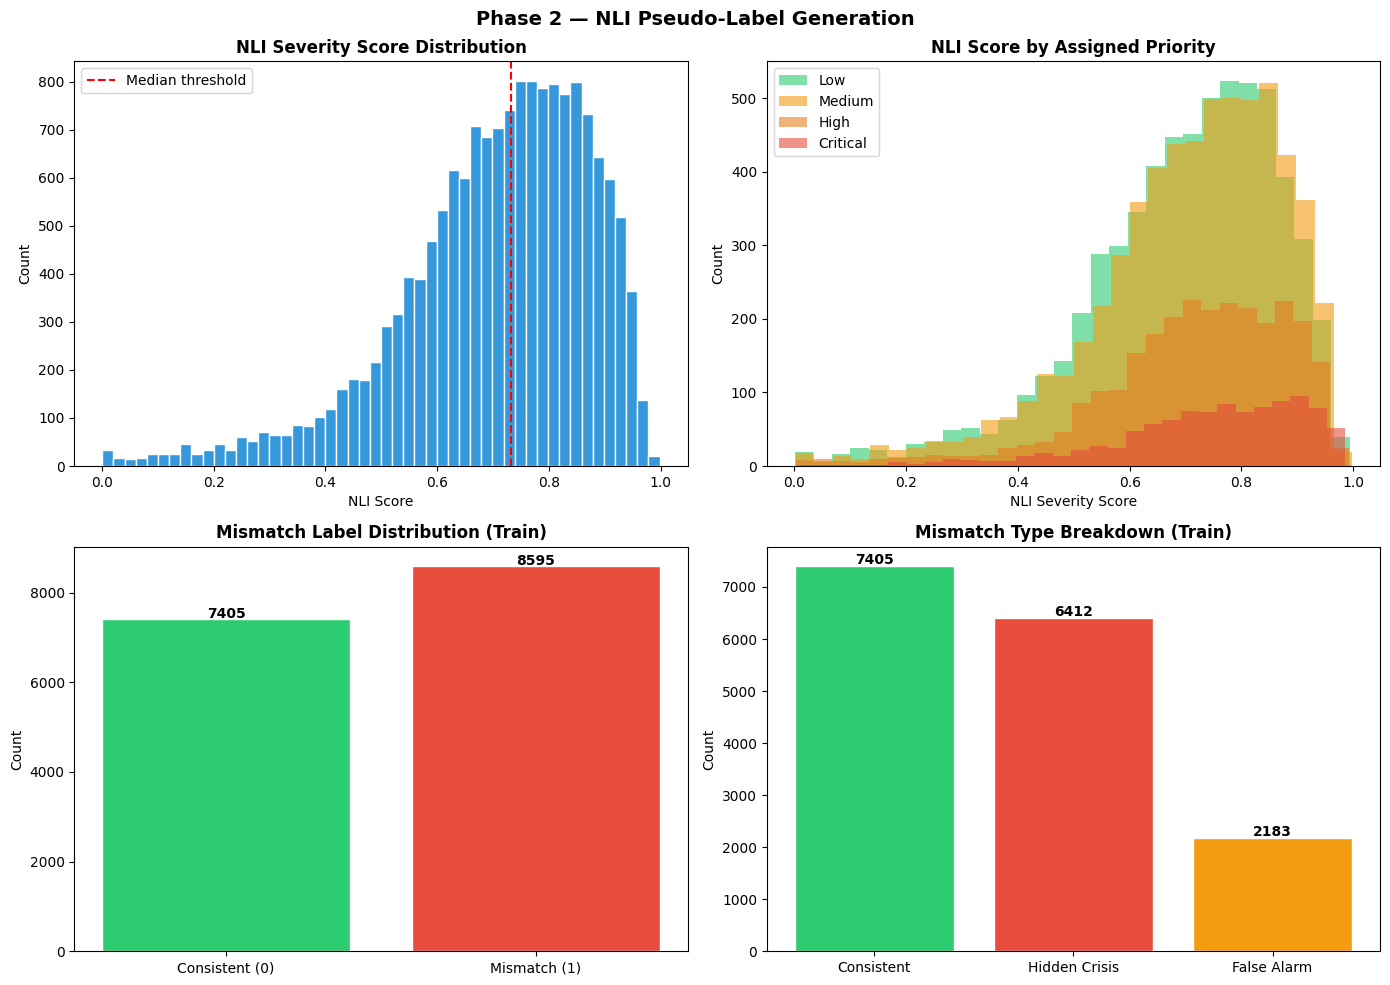

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Phase 2 — NLI Pseudo-Label Generation", fontweight="bold", fontsize=14)

# Plot 1: NLI score distribution
axes[0, 0].hist(train_df["nli_severity_score"], bins=50,
                color="#3498db", edgecolor="white")
axes[0, 0].axvline(x=train_df["nli_severity_score"].median(),
                   color="red", linestyle="--", label="Median threshold")
axes[0, 0].set_title("NLI Severity Score Distribution", fontweight="bold")
axes[0, 0].set_xlabel("NLI Score")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# Plot 2: NLI score by assigned priority — key validation plot
for i, p in enumerate(["Low", "Medium", "High", "Critical"]):
    mask = train_df["Priority_Level"] == p
    axes[0, 1].hist(
        train_df.loc[mask, "nli_severity_score"],
        bins=30, alpha=0.6, label=p,
        color=["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"][i]
    )
axes[0, 1].set_title("NLI Score by Assigned Priority", fontweight="bold")
axes[0, 1].set_xlabel("NLI Severity Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# Plot 3: Mismatch label distribution
vc = train_df["mismatch_label"].value_counts()
axes[1, 0].bar(
    ["Consistent (0)", "Mismatch (1)"],
    [vc[0], vc[1]],
    color=["#2ecc71", "#e74c3c"], edgecolor="white"
)
axes[1, 0].set_title("Mismatch Label Distribution (Train)", fontweight="bold")
axes[1, 0].set_ylabel("Count")
for i, v in enumerate([vc[0], vc[1]]):
    axes[1, 0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Plot 4: Mismatch type breakdown
type_order  = ["Consistent", "Hidden Crisis", "False Alarm"]
type_counts = [train_df["mismatch_type"].value_counts().get(t, 0) for t in type_order]
axes[1, 1].bar(type_order, type_counts,
               color=["#2ecc71", "#e74c3c", "#f39c12"], edgecolor="white")
axes[1, 1].set_title("Mismatch Type Breakdown (Train)", fontweight="bold")
axes[1, 1].set_ylabel("Count")
for i, v in enumerate(type_counts):
    axes[1, 1].text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [69]:
print("=== FINAL PHASE 2 STATE ===")
print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print(f"\nRequired columns present:")
for col in ["clean_text", "mismatch_label", "mismatch_type",
            "inferred_severity", "priority_binary",
            "channel_encoded", "category_encoded", "resolution_time_norm"]:
    status = "✅" if col in train_df.columns else "❌"
    print(f"  {status} {col}")

print(f"\nNull check:")
check_cols = ["mismatch_label", "mismatch_type", "inferred_severity"]
print(train_df[check_cols].isnull().sum())

=== FINAL PHASE 2 STATE ===
Train rows: 16000 | Test rows: 4000

Required columns present:
  ✅ clean_text
  ✅ mismatch_label
  ✅ mismatch_type
  ✅ inferred_severity
  ✅ priority_binary
  ✅ channel_encoded
  ✅ category_encoded
  ✅ resolution_time_norm

Null check:
mismatch_label       0
mismatch_type        0
inferred_severity    0
dtype: int64


In [71]:
!pip install umap-learn -q
import umap.umap_ as umap
from sentence_transformers import SentenceTransformer

# ── ENCODE EMBEDDINGS ─────────────────────────────────────────────────────────
print("Loading sentence transformer...")
sbert = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding train embeddings...")
train_embeddings = sbert.encode(
    train_df["clean_text"].tolist(),
    batch_size=128, show_progress_bar=True, convert_to_numpy=True
)

print("Encoding test embeddings...")
test_embeddings = sbert.encode(
    test_df["clean_text"].tolist(),
    batch_size=128, show_progress_bar=True, convert_to_numpy=True
)

print("Train embeddings shape:", train_embeddings.shape)
print("Test embeddings shape: ", test_embeddings.shape)

Loading sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding train embeddings...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Encoding test embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Train embeddings shape: (16000, 384)
Test embeddings shape:  (4000, 384)


In [72]:
# ── FIT UMAP ON TRAIN ONLY ────────────────────────────────────────────────────
print("Fitting UMAP on train...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
train_2d = reducer.fit_transform(train_embeddings)

print("Transforming test...")
test_2d = reducer.transform(test_embeddings)

train_df["umap_x"] = train_2d[:, 0]
train_df["umap_y"] = train_2d[:, 1]
test_df["umap_x"]  = test_2d[:, 0]
test_df["umap_y"]  = test_2d[:, 1]

print("UMAP done ✅")

Fitting UMAP on train...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Transforming test...
UMAP done ✅


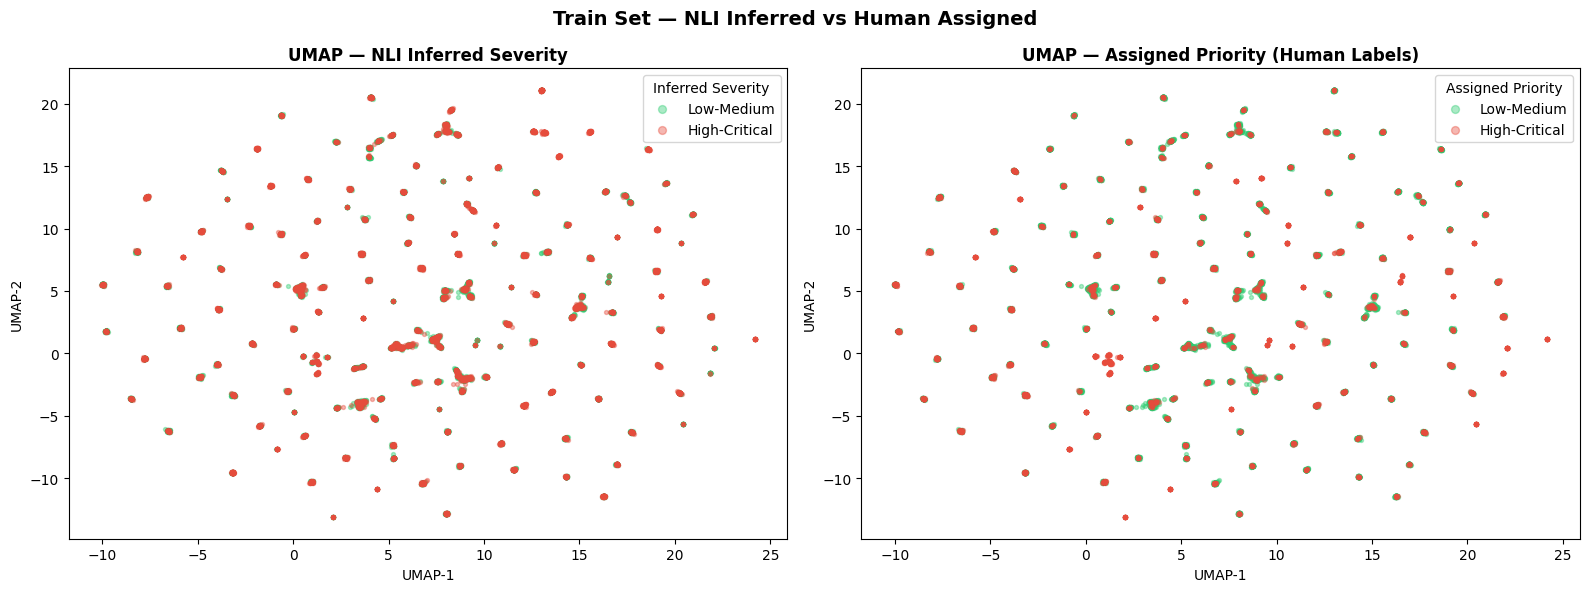

In [73]:
# ── PLOT 1: UMAP colored by Inferred Severity vs Assigned Priority ────────────
binary_colors = ["#2ecc71", "#e74c3c"]
binary_labels = {0: "Low-Medium", 1: "High-Critical"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sev in [0, 1]:
    mask = train_df["inferred_severity"] == sev
    axes[0].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=binary_colors[sev], label=binary_labels[sev],
        alpha=0.4, s=8
    )
axes[0].set_title("UMAP — NLI Inferred Severity", fontweight="bold")
axes[0].legend(title="Inferred Severity", markerscale=2)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

for sev in [0, 1]:
    mask = train_df["priority_binary"] == sev
    axes[1].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=binary_colors[sev], label=binary_labels[sev],
        alpha=0.4, s=8
    )
axes[1].set_title("UMAP — Assigned Priority (Human Labels)", fontweight="bold")
axes[1].legend(title="Assigned Priority", markerscale=2)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.suptitle("Train Set — NLI Inferred vs Human Assigned", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

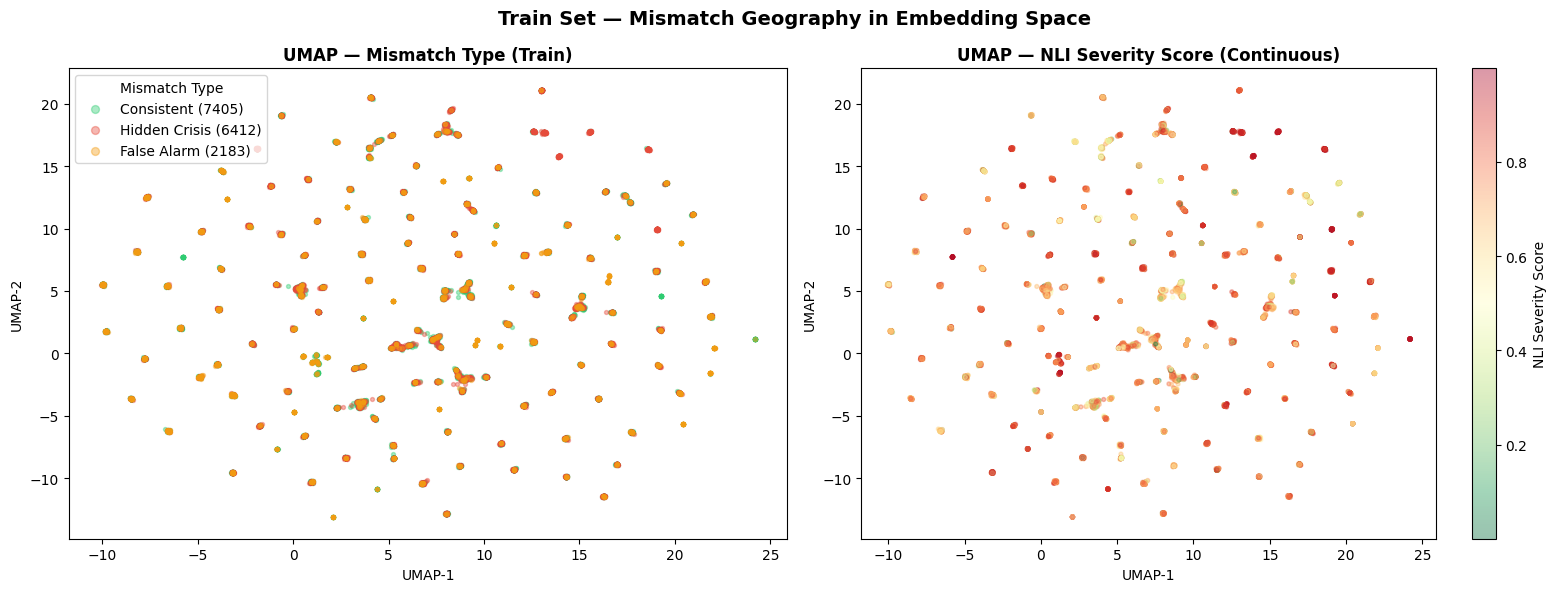

In [74]:
# ── PLOT 2: UMAP colored by Mismatch Type ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_colors = {
    "Consistent":   "#2ecc71",
    "Hidden Crisis": "#e74c3c",
    "False Alarm":  "#f39c12"
}

for mtype, color in type_colors.items():
    mask = train_df["mismatch_type"] == mtype
    axes[0].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=color, label=f"{mtype} ({mask.sum()})",
        alpha=0.4, s=8
    )
axes[0].set_title("UMAP — Mismatch Type (Train)", fontweight="bold")
axes[0].legend(title="Mismatch Type", markerscale=2)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

# ── PLOT 3: UMAP colored by NLI score (continuous heatmap) ───────────────────
scatter = axes[1].scatter(
    train_df["umap_x"],
    train_df["umap_y"],
    c=train_df["nli_severity_score"],
    cmap="RdYlGn_r",   # red=high severity, green=low severity
    alpha=0.4, s=8
)
plt.colorbar(scatter, ax=axes[1], label="NLI Severity Score")
axes[1].set_title("UMAP — NLI Severity Score (Continuous)", fontweight="bold")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.suptitle("Train Set — Mismatch Geography in Embedding Space",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

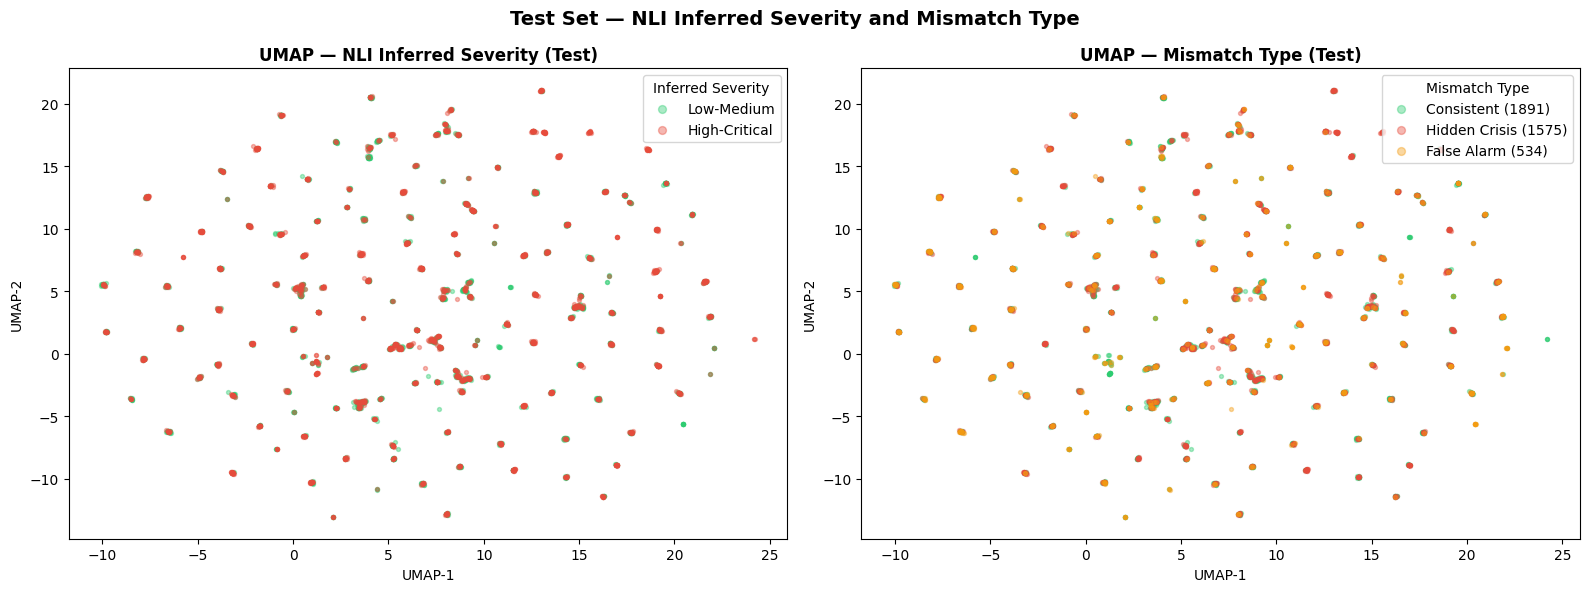

In [75]:
# ── PLOT 3: UMAP for TEST SET ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sev in [0, 1]:
    mask = test_df["inferred_severity"] == sev
    axes[0].scatter(
        test_df.loc[mask, "umap_x"],
        test_df.loc[mask, "umap_y"],
        c=binary_colors[sev], label=binary_labels[sev],
        alpha=0.4, s=8
    )
axes[0].set_title("UMAP — NLI Inferred Severity (Test)", fontweight="bold")
axes[0].legend(title="Inferred Severity", markerscale=2)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

for mtype, color in type_colors.items():
    mask = test_df["mismatch_type"] == mtype
    axes[1].scatter(
        test_df.loc[mask, "umap_x"],
        test_df.loc[mask, "umap_y"],
        c=color, label=f"{mtype} ({mask.sum()})",
        alpha=0.4, s=8
    )
axes[1].set_title("UMAP — Mismatch Type (Test)", fontweight="bold")
axes[1].legend(title="Mismatch Type", markerscale=2)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.suptitle("Test Set — NLI Inferred Severity and Mismatch Type",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Classifier training

In [76]:
# ── PHASE 3: CLASSIFIER TRAINING ─────────────────────────────────────────────

MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded ✅")

Tokenizer loaded ✅


In [77]:
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts      = df["clean_text"].tolist()
        self.labels     = df["mismatch_label"].tolist()
        self.channels   = df["channel_encoded"].tolist()
        self.categories = df["category_encoded"].tolist()
        self.res_times  = df["resolution_time_norm"].tolist()
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "channel":        torch.tensor(self.channels[idx],   dtype=torch.float),
            "category":       torch.tensor(self.categories[idx], dtype=torch.float),
            "res_time":       torch.tensor(self.res_times[idx],  dtype=torch.float),
            "label":          torch.tensor(self.labels[idx],     dtype=torch.long)
        }

train_dataset = TicketDataset(train_df, tokenizer, MAX_LEN)
test_dataset  = TicketDataset(test_df,  tokenizer, MAX_LEN)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

sample = train_dataset[0]
print("Sample keys:    ", list(sample.keys()))
print("input_ids shape:", sample["input_ids"].shape)
print("label:          ", sample["label"].item())

Train batches: 500 | Test batches: 125
Sample keys:     ['input_ids', 'attention_mask', 'channel', 'category', 'res_time', 'label']
input_ids shape: torch.Size([128])
label:           1


In [78]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query_proj", "value_proj"],
    inference_mode=False
)

class DeBERTaLoRAWithMetadata(nn.Module):
    def __init__(self, model_name, lora_config, n_metadata=3, n_classes=2, dropout=0.3):
        super().__init__()
        base_model      = AutoModel.from_pretrained(model_name)
        self.deberta    = get_peft_model(base_model, lora_config)
        self.deberta.print_trainable_parameters()
        hidden_size     = base_model.config.hidden_size

        self.meta_proj  = nn.Sequential(
            nn.Linear(n_metadata, 32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 32, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask, channel, category, res_time):
        outputs    = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        meta       = torch.stack([channel, category, res_time], dim=1)
        meta_out   = self.meta_proj(meta)
        combined   = torch.cat([cls_output, meta_out], dim=1)
        return self.classifier(combined)

print("Loading model...")
model_clf = DeBERTaLoRAWithMetadata(MODEL_NAME, lora_config).to(device)
print("Model ready ✅")

Loading model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 141,451,776 || trainable%: 0.1042
Model ready ✅


In [79]:
# Mild class weights — 46/54 split doesn't need aggressive weighting
class_counts  = train_df["mismatch_label"].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (2 * class_counts), dtype=torch.float
).to(device)
print(f"Class weights → Consistent(0): {class_weights[0]:.4f} | Mismatch(1): {class_weights[1]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_clf.parameters()),
    lr=LR, weight_decay=0.01
)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

Class weights → Consistent(0): 1.0804 | Mismatch(1): 0.9308
Total steps: 2500 | Warmup steps: 250


In [80]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for i, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        channel        = batch["channel"].to(device)
        category       = batch["category"].to(device)
        res_time       = batch["res_time"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, channel, category, res_time)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (i + 1) % 100 == 0:
            print(f"  Batch {i+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro")
    )

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            channel        = batch["channel"].to(device)
            category       = batch["category"].to(device)
            res_time       = batch["res_time"].to(device)
            labels         = batch["label"].to(device)

            logits      = model(input_ids, attention_mask, channel, category, res_time)
            loss        = criterion(logits, labels)
            total_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
        all_preds, all_labels
    )

In [81]:
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    train_loss, train_acc, train_f1 = train_epoch(
        model_clf, train_loader, optimizer, scheduler, criterion, device
    )
    val_loss, val_acc, val_f1, val_preds, val_labels = eval_epoch(
        model_clf, test_loader, criterion, device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss":   val_loss,   "val_acc":   val_acc,   "val_f1":   val_f1
    })

    print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")


EPOCH 1/5
  Batch 100/500 | Loss: 0.6877
  Batch 200/500 | Loss: 0.7114
  Batch 300/500 | Loss: 0.6988
  Batch 400/500 | Loss: 0.7030
  Batch 500/500 | Loss: 0.7049
Train → Loss: 0.7041 | Acc: 0.5027 | F1: 0.4991
Val   → Loss: 0.6911 | Acc: 0.5350 | F1: 0.5217

EPOCH 2/5
  Batch 100/500 | Loss: 0.7072
  Batch 200/500 | Loss: 0.7375
  Batch 300/500 | Loss: 0.7055
  Batch 400/500 | Loss: 0.7058
  Batch 500/500 | Loss: 0.6782
Train → Loss: 0.6965 | Acc: 0.5109 | F1: 0.5105
Val   → Loss: 0.6889 | Acc: 0.6038 | F1: 0.6037

EPOCH 3/5
  Batch 100/500 | Loss: 0.7091
  Batch 200/500 | Loss: 0.7161
  Batch 300/500 | Loss: 0.6961
  Batch 400/500 | Loss: 0.7214
  Batch 500/500 | Loss: 0.6646
Train → Loss: 0.6942 | Acc: 0.5201 | F1: 0.5199
Val   → Loss: 0.6871 | Acc: 0.5978 | F1: 0.5898

EPOCH 4/5
  Batch 100/500 | Loss: 0.6763
  Batch 200/500 | Loss: 0.6833
  Batch 300/500 | Loss: 0.7347
  Batch 400/500 | Loss: 0.6807
  Batch 500/500 | Loss: 0.6779
Train → Loss: 0.6908 | Acc: 0.5331 | F1: 0.5328


In [82]:
print("\n=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(
    val_labels, val_preds,
    target_names=["Consistent (0)", "Mismatch (1)"],
    digits=4
))

recalls = recall_score(val_labels, val_preds, average=None)
print("=== VERIFICATION THRESHOLD CHECK ===")
print(f"Accuracy ≥ 0.83:        {'✅' if val_acc    >= 0.83 else '❌'} ({val_acc:.4f})")
print(f"Macro F1 ≥ 0.82:        {'✅' if val_f1     >= 0.82 else '❌'} ({val_f1:.4f})")
print(f"Recall class 0 ≥ 0.78:  {'✅' if recalls[0] >= 0.78 else '❌'} ({recalls[0]:.4f})")
print(f"Recall class 1 ≥ 0.78:  {'✅' if recalls[1] >= 0.78 else '❌'} ({recalls[1]:.4f})")


=== FINAL CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

Consistent (0)     0.6022    0.6838    0.6404      1891
  Mismatch (1)     0.6773    0.5951    0.6335      2109

      accuracy                         0.6370      4000
     macro avg     0.6398    0.6394    0.6370      4000
  weighted avg     0.6418    0.6370    0.6368      4000

=== VERIFICATION THRESHOLD CHECK ===
Accuracy ≥ 0.83:        ❌ (0.6370)
Macro F1 ≥ 0.82:        ❌ (0.6370)
Recall class 0 ≥ 0.78:  ❌ (0.6838)
Recall class 1 ≥ 0.78:  ❌ (0.5951)


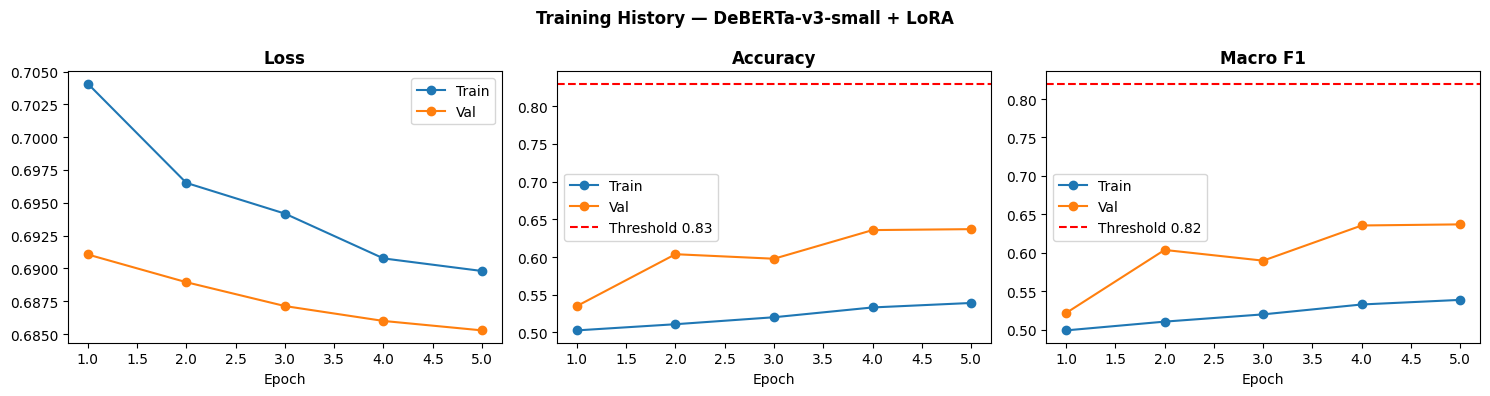

In [83]:
# Plot training history
history_df = pd.DataFrame(history)
fig, axes  = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   marker="o", label="Val")
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train")
axes[1].plot(history_df["epoch"], history_df["val_acc"],   marker="o", label="Val")
axes[1].axhline(y=0.83, color="red", linestyle="--", label="Threshold 0.83")
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["train_f1"], marker="o", label="Train")
axes[2].plot(history_df["epoch"], history_df["val_f1"],   marker="o", label="Val")
axes[2].axhline(y=0.82, color="red", linestyle="--", label="Threshold 0.82")
axes[2].set_title("Macro F1", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("Training History — DeBERTa-v3-small + LoRA", fontweight="bold")
plt.tight_layout()
plt.show()